In [22]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.metrics import root_mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.metrics import accuracy_score, precision_score, recall_score, classification_report, confusion_matrix
import joblib as jb
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import plot_tree
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import GridSearchCV

from sklearn.metrics import silhouette_score


In [23]:
# load dataset
df = pd.read_csv("Resources/auto_mpg_cleaned.csv")
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 392 entries, 0 to 391
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   mpg           392 non-null    float64
 1   cylinders     392 non-null    int64  
 2   displacement  392 non-null    float64
 3   horsepower    392 non-null    int64  
 4   weight        392 non-null    int64  
 5   acceleration  392 non-null    float64
 6   model year    392 non-null    int64  
 7   origin        392 non-null    int64  
 8   car name      392 non-null    object 
dtypes: float64(3), int64(5), object(1)
memory usage: 27.7+ KB


In [24]:
df.head()

,mpg,cylinders,displacement,horsepower,weight,acceleration,model year,origin,car name
0,18.0,8,307.0,130,3504,12.0,70,1,chevrolet chevelle malibu
1,15.0,8,350.0,165,3693,11.5,70,1,buick skylark 320
2,18.0,8,318.0,150,3436,11.0,70,1,plymouth satellite
3,16.0,8,304.0,150,3433,12.0,70,1,amc rebel sst
4,17.0,8,302.0,140,3449,10.5,70,1,ford torino


In [25]:
df['origin'].value_counts()

origin
1    245
3     79
2     68
Name: count, dtype: int64

In [26]:
df.columns

Index(['mpg', 'cylinders', 'displacement', 'horsepower', 'weight',
       'acceleration', 'model year', 'origin', 'car name'],
      dtype='object')

In [27]:
df.drop(columns=['car name'], axis=1, inplace=True)

In [28]:
df.head(2)

,mpg,cylinders,displacement,horsepower,weight,acceleration,model year,origin
0,18.0,8,307.0,130,3504,12.0,70,1
1,15.0,8,350.0,165,3693,11.5,70,1


In [29]:
df.isna().sum()

mpg             0
cylinders       0
displacement    0
horsepower      0
weight          0
acceleration    0
model year      0
origin          0
dtype: int64

In [30]:
X = df.drop(columns=['mpg'], axis=1)
y = (df['mpg'] > df['mpg'].median()).astype(int)

In [31]:
# train test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [32]:
# scaled and normalized data
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [33]:
model = LogisticRegression()
model.fit(X_train_scaled, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [34]:
y_pred = model.predict(X_test_scaled)
y_pred[:10]

array([1, 1, 1, 1, 1, 1, 0, 1, 0, 1])

In [35]:
# confusion matrix
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(y_test, y_pred)
cm

array([[32, 10],
       [ 2, 35]])

In [36]:
print(f"Accuracy of model is {accuracy_score(y_test, y_pred)*100:.2f}%")
print(f"Precision of model is {precision_score(y_test, y_pred)*100:.2f}%")
print(f"Recall of model is {recall_score(y_test, y_pred)*100:.2f}%")

Accuracy of model is 84.81%
Precision of model is 77.78%
Recall of model is 94.59%


              precision    recall  f1-score   support

           0       0.94      0.76      0.84        42
           1       0.78      0.95      0.85        37

    accuracy                           0.85        79
   macro avg       0.86      0.85      0.85        79
weighted avg       0.86      0.85      0.85        79



<Axes: >

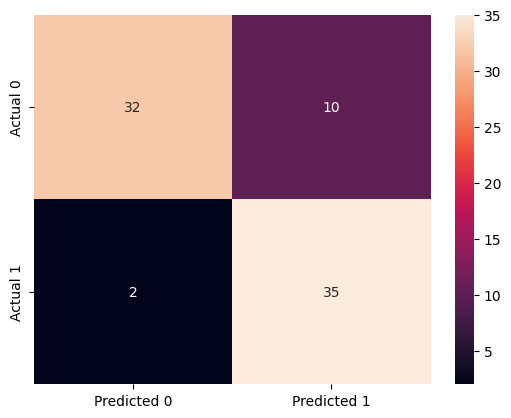

In [37]:
print(classification_report(y_test, y_pred))
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', xticklabels=['Predicted 0', 'Predicted 1'], yticklabels=['Actual 0', 'Actual 1'])

In [38]:
jb.dump(model, 'logistic_model.pkl')
jb.dump(scaler, 'mpg_scaler.pkl')

['mpg_scaler.pkl']

In [39]:
#load the model
model = jb.load('logistic_model.pkl')
scale = jb.load('mpg_scaler.pkl')

In [40]:
cyl = int(input("Enter the number of cylinders(2 to 10): "))
dsp = float(input("Enter displacement(60 to 550): "))
hp = float(input("Enter horsepower(40 to 300): "))
wt = int(input("Enter weight(1600 to 5200): "))
acc = int(input("Enter acceleration(2 to 26): "))
mody = int(input("Enter model year(70 to 98): "))
org = int(input("Enter origin(1 for USA, 2 for Japan, 3 for Europe): "))

#convert it numpy array
new_data = np.array([[cyl, dsp, hp, wt, acc, mody, org]])

#scale the data
new_data_scaled = scaler.transform(new_data)

#prediction
prediction = model.predict(new_data_scaled)
print(prediction)

if prediction[0] == 1:
    print("The car is likely to have good mileage.")
else:
    print("The car is likely to have poor mileage.")

[1]
The car is likely to have good mileage.


/home/haze/.local/lib/python3.14/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


Accuracy of Naive Bayes model is 87.34%
Precision of Naive Bayes model is 80.00%
Recall of Naive Bayes model is 97.30%
              precision    recall  f1-score   support

           0       0.97      0.79      0.87        42
           1       0.80      0.97      0.88        37

    accuracy                           0.87        79
   macro avg       0.89      0.88      0.87        79
weighted avg       0.89      0.87      0.87        79



<Axes: >

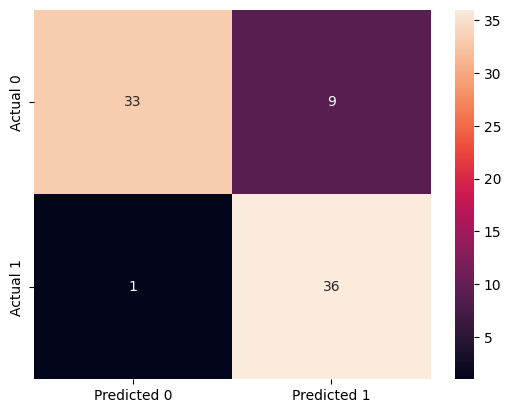

In [41]:
nb_model = GaussianNB()
nb_model.fit(X_train_scaled, y_train)
y_nb_pred = nb_model.predict(X_test_scaled)
print(f"Accuracy of Naive Bayes model is {accuracy_score(y_test, y_nb_pred)*100:.2f}%")
print(f"Precision of Naive Bayes model is {precision_score(y_test, y_nb_pred)*100:.2f}%")
print(f"Recall of Naive Bayes model is {recall_score(y_test, y_nb_pred)*100:.2f}%")
print(classification_report(y_test, y_nb_pred))
cm_nb = confusion_matrix(y_test, y_nb_pred)
sns.heatmap(cm_nb, annot=True, fmt='d', xticklabels=['Predicted 0', 'Predicted 1'], yticklabels=['Actual 0', 'Actual 1'])

Accuracy of KNN model is 88.61%
Precision of KNN model is 81.82%
Recall of KNN model is 97.30%


<Axes: >

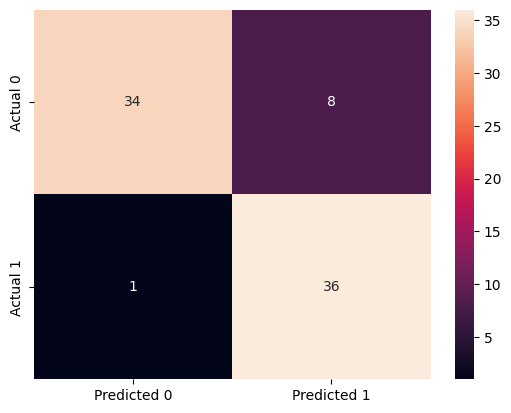

In [42]:
# implementing KNN
knn_model = KNeighborsClassifier(n_neighbors=5)
knn_model.fit(X_train_scaled, y_train)
y_knn_pred = knn_model.predict(X_test_scaled)
print(f"Accuracy of KNN model is {accuracy_score(y_test, y_knn_pred)*100:.2f}%")
print(f"Precision of KNN model is {precision_score(y_test, y_knn_pred)*100:.2f}%")
print(f"Recall of KNN model is {recall_score(y_test, y_knn_pred)*100:.2f}%")
# plot KNN
cm_knn = confusion_matrix(y_test, y_knn_pred)
sns.heatmap(cm_knn, annot=True, fmt='d', xticklabels=['Predicted 0', 'Predicted 1'], yticklabels=['Actual 0', 'Actual 1'])

In [43]:
# 27 feb 2026

In [44]:
# implementing decision tree
dt_model = DecisionTreeClassifier(max_depth=5, random_state=42)
dt_model.fit(X_train_scaled, y_train)


,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",5
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",42
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current no

In [45]:
y_dt_pred = dt_model.predict(X_test_scaled)
print(f"Accuracy of Decision Tree model is {accuracy_score(y_test, y_dt_pred)*100:.2f}%")
print(f"Precision of Decision Tree model is {precision_score(y_test, y_dt_pred)*100:.2f}%")
print(f"Recall of Decision Tree model is {recall_score(y_test, y_dt_pred)*100:.2f}%")


Accuracy of Decision Tree model is 89.87%
Precision of Decision Tree model is 83.72%
Recall of Decision Tree model is 97.30%


In [46]:
y_dt_pred[:10]

array([1, 0, 1, 1, 1, 1, 0, 1, 0, 1])

In [47]:
print(classification_report(y_test, y_dt_pred))

              precision    recall  f1-score   support

           0       0.97      0.83      0.90        42
           1       0.84      0.97      0.90        37

    accuracy                           0.90        79
   macro avg       0.90      0.90      0.90        79
weighted avg       0.91      0.90      0.90        79



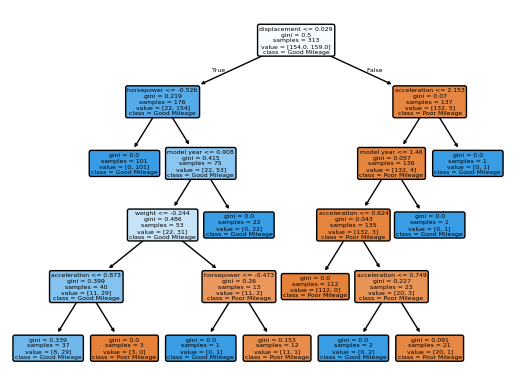

In [48]:
plot_tree(dt_model, feature_names=X.columns, class_names=['Poor Mileage', 'Good Mileage'], filled=True, rounded=True)
plt.show()

In [49]:
#random forest
mpg_model_rforest = RandomForestClassifier(n_estimators=20,random_state=42)
mpg_model_rforest.fit(X_train_scaled, y_train)
y_pred_rforest = mpg_model_rforest.predict(X_test_scaled)
y_pred_rforest[:10]

array([1, 0, 1, 1, 1, 1, 0, 1, 0, 1])

In [50]:
print(classification_report(y_test, y_pred_rforest))

              precision    recall  f1-score   support

           0       0.97      0.90      0.94        42
           1       0.90      0.97      0.94        37

    accuracy                           0.94        79
   macro avg       0.94      0.94      0.94        79
weighted avg       0.94      0.94      0.94        79



In [51]:
#svm
mpg_model_svm = SVC(kernel='rbf', C=0.01, gamma='scale')
mpg_model_svm.fit(X_train_scaled, y_train)
y_pred_svm = mpg_model_svm.predict(X_test_scaled)
y_pred_svm[:10]


array([1, 1, 1, 1, 1, 1, 0, 1, 1, 1])

In [52]:
print(classification_report(y_test, y_pred_svm))

              precision    recall  f1-score   support

           0       1.00      0.52      0.69        42
           1       0.65      1.00      0.79        37

    accuracy                           0.75        79
   macro avg       0.82      0.76      0.74        79
weighted avg       0.84      0.75      0.73        79



In [53]:
#hyperparameter tuning on svm
pram_grid = {
    'C': [0.01, 0.1, 1, 10],
    'kernel': ['linear', 'poly'],
    'gamma': ['scale', 'auto', 1, 0.01, 0.1, 10, 100],
}

In [54]:
grid = GridSearchCV(mpg_model_svm, pram_grid, cv=5, n_jobs=-1, scoring='accuracy', verbose=2)

In [55]:
grid.fit(X_train_scaled, y_train)

Fitting 5 folds for each of 56 candidates, totalling 280 fits


[CV] END ...................C=0.01, gamma=scale, kernel=poly; total time=   0.0s
[CV] END .................C=0.01, gamma=scale, kernel=linear; total time=   0.0s
[CV] END .....................C=0.01, gamma=1, kernel=linear; total time=   0.0s
[CV] END .....................C=0.01, gamma=1, kernel=linear; total time=   0.0s
[CV] END .....................C=0.01, gamma=1, kernel=linear; total time=   0.0s
[CV] END .......................C=0.01, gamma=1, kernel=poly; total time=   0.0s
[CV] END .......................C=0.01, gamma=1, kernel=poly; total time=   0.0s
[CV] END .......................C=0.01, gamma=1, kernel=poly; total time=   0.0s
[CV] END .......................C=0.01, gamma=1, kernel=poly; total time=   0.0s
[CV] END ..................C=0.01, gamma=auto, kernel=linear; total time=   0.0s
[CV] END .......................C=0.01, gamma=1, kernel=poly; total time=   0.0s
[CV] END ..................C=0.01, gamma=0.01, kernel=linear; total time=   0.0s
[CV] END ..................C

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",SVC(C=0.01)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'C': [0.01, 0.1, ...], 'gamma': ['scale', 'auto', ...], 'kernel': ['linear', 'poly']}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'accuracy'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candidate is displayed;- >2 : the score is also d

In [56]:
grid.best_estimator_

,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive. The penaltyis a squared l2 penalty. For an intuitive visualization of the effectsof scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",0.1
,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm. Ifnone is given, 'rbf' will be used. If a callable is given it is used topre-compute the kernel matrix from data matrices; that matrix should bean array of shape ``(n_samples, n_samples)``. For an intuitivevisualization of different kernel types see:ref:`sphx_glr_auto_examples_svm_plot_svm_kernels.py`.",'linear'
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",'scale'
,"coef0 coef0: float, default=0.0Independent term in kernel function.It is only significant in 'poly' and 'sigmoid'.",0.0
,"shrinking shrinking: bool, default=TrueWhether to use the shrinking heuristic.See the :ref:`User Guide `.",True
,"probability probability: bool, default=FalseWhether to enable probability estimates. This must be enabled priorto calling `fit`, will slow down that method as it internally uses5-fold cross-validation, and `predict_proba` may be inconsistent with`predict`. Read more in the :ref:`User Guide `.",False
,"tol tol: float, default=1e-3Tolerance for stopping criterion.",0.001
,"cache_size cache_size: float, default=200Specify the size of the kernel cache (in MB).",200
,"class_weight class_weight: dict or 'balanced', default=NoneSet the parameter C of class i to class_weight[i]*C forSVC. If not given, all classes are supposed to haveweight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.",None
,"verbose verbose: bool, default=FalseEnable verbose output. Note that this setting takes advantage of aper-process runtime setting in libsvm that, if enabled, may not workproperly in a multithreaded context.",False


In [57]:
grid.best_params_

{'C': 0.1, 'gamma': 'scale', 'kernel': 'linear'}

In [58]:
grid.best_score_

np.float64(0.923399897593446)

In [59]:
#save the model
jb.dump(mpg_model_svm, 'svm_model.pkl')

['svm_model.pkl']

Unsupervised learning

In [60]:
#load mall cluster dataset from resources/mall_customers.csv 
mall_df = pd.read_csv("Resources/Mall_customers.csv")
mall_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   CustomerID              200 non-null    int64 
 1   Gender                  200 non-null    object
 2   Age                     200 non-null    int64 
 3   Annual Income (k$)      200 non-null    int64 
 4   Spending Score (1-100)  200 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 7.9+ KB


In [61]:
mall_df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [62]:
#check missing values
mall_df.isna().sum()

CustomerID                0
Gender                    0
Age                       0
Annual Income (k$)        0
Spending Score (1-100)    0
dtype: int64

In [63]:
scaler = StandardScaler()
X = mall_df[['Age', 'Annual Income (k$)', 'Spending Score (1-100)']]
X_test_scaled = scaler.fit_transform(X)

In [64]:
#kmeans
from sklearn.cluster import KMeans
mall_cluster_kmeans = KMeans(n_clusters=3, init='k-means++', random_state=42)
mall_df["cluster"] = mall_cluster_kmeans.fit_predict(X_test_scaled)
mall_df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100),cluster
0,1,Male,19,15,39,2
1,2,Male,21,15,81,2
2,3,Female,20,16,6,2
3,4,Female,23,16,77,2
4,5,Female,31,17,40,2


In [65]:
wcss = []
for k in range(1, 11):
    kmeans_model = KMeans(n_clusters=k, init='k-means++', random_state=42)
    kmeans_model.fit(X_test_scaled)
    wcss.append(kmeans_model.inertia_)
print(wcss)

[599.9999999999999, 389.38618895643714, 295.4562449213557, 205.2251474767592, 169.89149793438585, 134.35277477401493, 121.3893502250287, 113.72723000071335, 102.13623844329253, 92.55027231838785]


/tmp/ipykernel_8328/2152813631.py:4: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


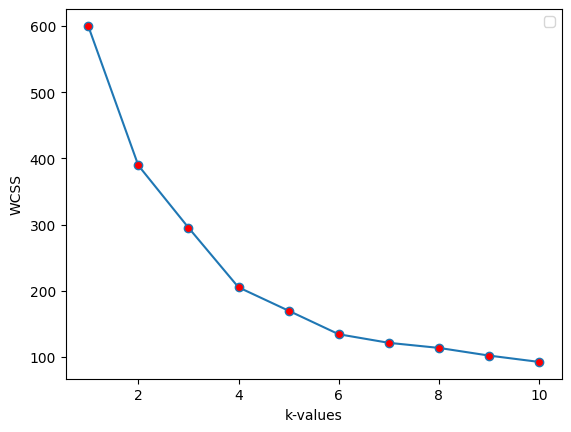

In [66]:
plt.plot(range(1, 11), wcss, marker='o', mfc = 'red')
plt.xlabel('k-values')
plt.ylabel('WCSS')
plt.legend()
plt.show()

<Axes: xlabel='Annual Income (k$)', ylabel='Spending Score (1-100)'>

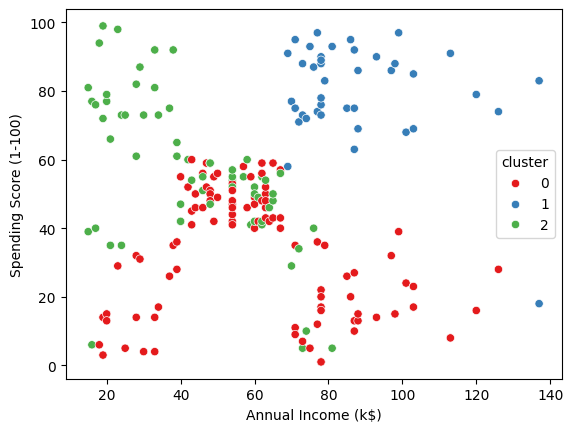

In [67]:
sns.scatterplot(x='Annual Income (k$)', y='Spending Score (1-100)', hue='cluster', data=mall_df, palette='Set1')

In [68]:
#calculate shiliute score



silhouette_avg = silhouette_score(X_test_scaled, mall_df["cluster"])
print("The average silhouette score is:", silhouette_avg)

The average silhouette score is: 0.3579234303882264


lab?

In [70]:
env_df = pd.read_csv("Resources/environmental factors.csv")
env_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 6 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   temperature       10000 non-null  float64
 1   humidity          10000 non-null  float64
 2   wind_speed        10000 non-null  float64
 3   carbon_emissions  10000 non-null  float64
 4   solar_irradiance  10000 non-null  float64
 5   pollution_level   10000 non-null  float64
dtypes: float64(6)
memory usage: 468.9 KB


In [71]:
env_df.head()

,temperature,humidity,wind_speed,carbon_emissions,solar_irradiance,pollution_level
0,22.490802,52.418449,19.599966,337.165056,369.020837,84.723658
1,34.014286,49.974726,8.690240,256.681604,185.335998,49.451704
2,29.639879,40.569235,11.932794,484.024336,213.723302,19.546561
3,26.973170,66.436000,18.265613,148.540303,262.604015,73.664179
4,18.120373,58.597450,14.641787,314.535387,283.288001,41.867814


In [72]:
#check missing values
env_df.isna().sum()

temperature         0
humidity            0
wind_speed          0
carbon_emissions    0
solar_irradiance    0
pollution_level     0
dtype: int64

In [73]:
scaler = StandardScaler()
B = env_df[['temperature', 'humidity', 'wind_speed','carbon_emissions', 'solar_irradiance', 'pollution_level']]
B_test_scaled = scaler.fit_transform(B)

In [89]:
#kmeans
from sklearn.cluster import KMeans
env_cluster_kmeans = KMeans(n_clusters=2, init='k-means++', random_state=42)
env_df["cluster"] = env_cluster_kmeans.fit_predict(B_test_scaled)
env_df.head()

,temperature,humidity,wind_speed,carbon_emissions,solar_irradiance,pollution_level,cluster
0,22.490802,52.418449,19.599966,337.165056,369.020837,84.723658,1
1,34.014286,49.974726,8.690240,256.681604,185.335998,49.451704,0
2,29.639879,40.569235,11.932794,484.024336,213.723302,19.546561,0
3,26.973170,66.436000,18.265613,148.540303,262.604015,73.664179,1
4,18.120373,58.597450,14.641787,314.535387,283.288001,41.867814,0


In [90]:
wc = []
for i in range(1, 11):
    kmeans_model = KMeans(n_clusters=i, init='k-means++', random_state=42)
    kmeans_model.fit(B_test_scaled)
    wc.append(kmeans_model.inertia_)
print(wc)

[60000.0, 52500.98280316609, 47906.38033498901, 44158.489882761394, 41441.033684809765, 38890.806545878404, 36927.78831035683, 35222.43742101898, 33626.690829418054, 32262.8728778537]


/tmp/ipykernel_8328/3688376908.py:4: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


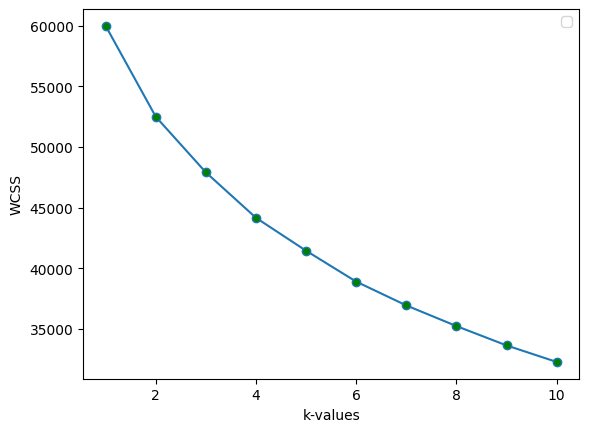

In [91]:
plt.plot(range(1, 11), wc, marker='o', mfc = 'green')
plt.xlabel('k-values')
plt.ylabel('WCSS')
plt.legend()
plt.show()

<Axes: xlabel='temperature', ylabel='humidity'>

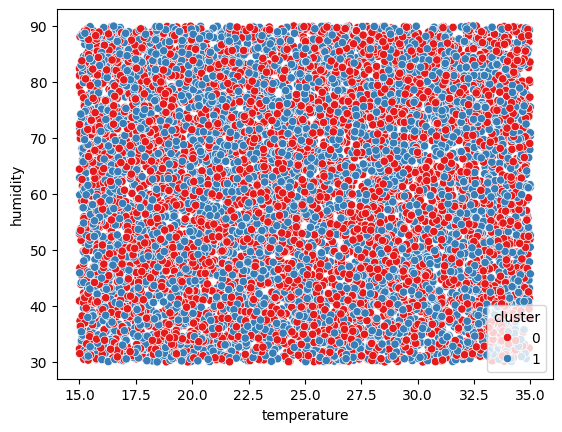

In [92]:
sns.scatterplot(x='temperature', y='humidity', hue='cluster', data=env_df, palette='Set1')

In [93]:
sil_env_score = silhouette_score(B_test_scaled, env_df['cluster'])
print(sil_env_score)

0.12329174489534976
